In [15]:
import pandas as pd
from utils.data_processing import process_string

import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
%matplotlib inline

## Approach 1: Training on microbiota composition

### Plotting Classifier and Regressor performances

In [16]:
performance_clr_auroc_all_vars = pd.read_csv(
    "./results/classifier_performance_auroc.csv", index_col=0
)
performance_clr_auprc_all_vars = pd.read_csv(
    "./results/classifier_performance_auprc.csv", index_col=0
)
performance_reg_all_vars = pd.read_csv(
    "./results/regressor_performance_full.csv", index_col=0
)

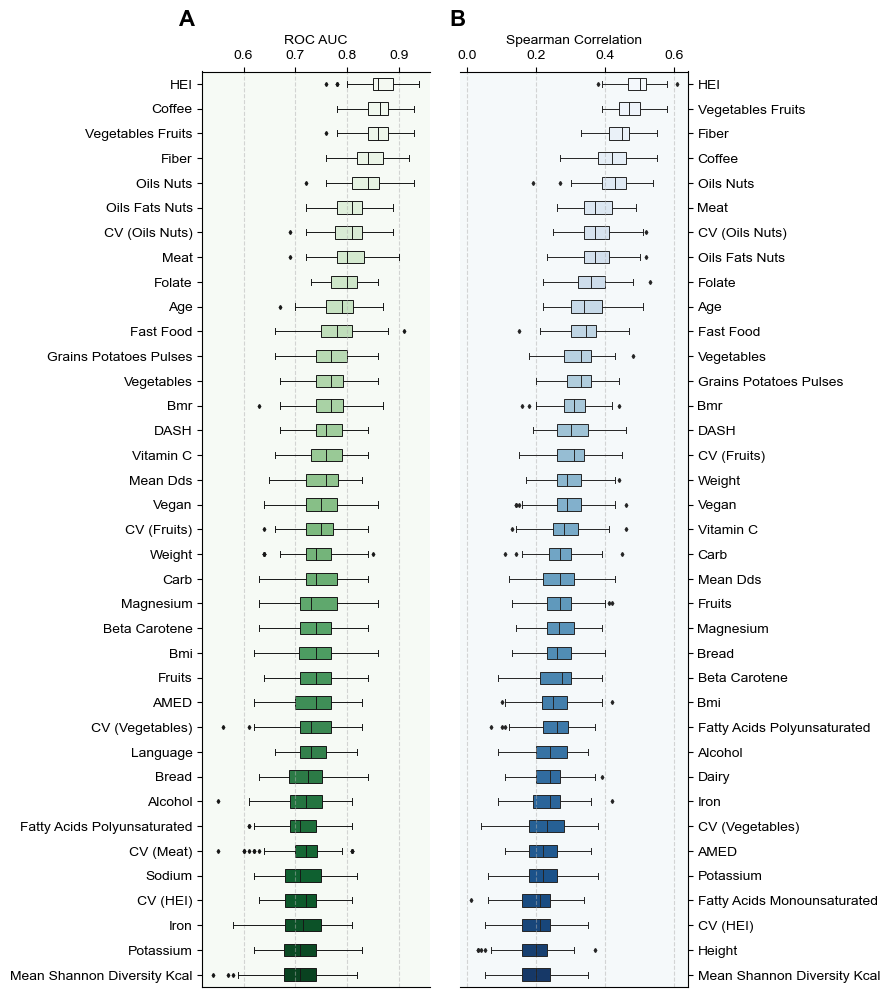

In [17]:
topn = 40

ignore_cols_for_model_performance_chart = [
    "dairy_products_meat_fish_eggs_tofu",
    "sweets_salty_snacks_alcohol",
    "alcohol_fg_eaten",
]

data_for_clr_plot = performance_clr_auroc_all_vars[
    performance_clr_auroc_all_vars.mean().sort_values(ascending=False).index[:topn]
]
data_for_clr_plot = data_for_clr_plot.drop(
    columns=ignore_cols_for_model_performance_chart, axis=1
)
data_for_clr_plot.columns = data_for_clr_plot.columns.map(
    lambda i: process_string(i, newLineSep=4)
)

data_for_reg_plot = performance_reg_all_vars[
    performance_reg_all_vars.mean().sort_values(ascending=False).index[:topn]
]
data_for_reg_plot = data_for_reg_plot.drop(
    columns=[
        i
        for i in ignore_cols_for_model_performance_chart
        if i in data_for_reg_plot.columns
    ],
    axis=1,
)
data_for_reg_plot.columns = data_for_reg_plot.columns.map(
    lambda i: process_string(i, newLineSep=4)
)

fig, ax = plt.subplots(ncols=2, figsize=(9, 10))

sns.boxplot(
    data_for_clr_plot,
    width=0.5,
    fliersize=2,
    linewidth=0.7,
    orient="h",
    ax=ax[0],
    palette="Greens",
)
# Move x-axis labels to the top
ax[0].xaxis.set_label_position("top")
ax[0].xaxis.tick_top()

# ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontname="Arial", fontsize=9.2, fontweight="normal", )
ax[0].set_xlabel("ROC AUC", fontname="Arial", fontsize=10, fontweight="light")
ax[0].grid(True, axis="x", linestyle="--", alpha=0.5)
ax[0].text(-0.1, 1.05, "A", fontsize=16, fontweight="bold", transform=ax[0].transAxes)


sns.boxplot(
    data_for_reg_plot,
    width=0.5,
    fliersize=2,
    linewidth=0.7,
    orient="h",
    ax=ax[1],
    palette="Blues",
)
# ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, fontname="Arial", fontsize=9.2, fontweight="normal", )
ax[1].set_xlabel(
    "Spearman Correlation", fontname="Arial", fontsize=10, fontweight="light"
)
ax[1].grid(True, axis="x", linestyle="--", alpha=0.5)
ax[1].text(-0.05, 1.05, "B", fontsize=16, fontweight="bold", transform=ax[1].transAxes)
# Move x-axis labels to the top
ax[1].xaxis.set_label_position("top")
ax[1].xaxis.tick_top()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

plt.tight_layout()

# ax[0].spines['bottom'].set_visible(False)
ax[0].spines["right"].set_visible(False)
# ax[1].spines['bottom'].set_visible(False)
ax[1].spines["left"].set_visible(False)

ax[0].set_facecolor("#f6faf5")
ax[1].set_facecolor("#f5f9fa")

## save figure
plt.savefig(
    "../../figures/ml_analysis/model_performances.png", dpi=300, bbox_inches="tight"
)

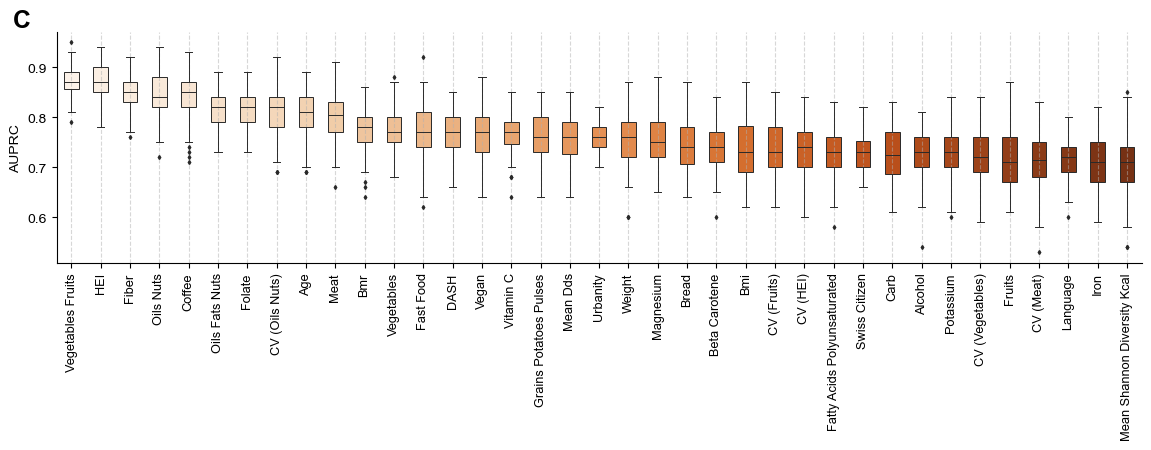

In [18]:
topn = 40

ignore_cols_for_model_performance_chart = [
    "dairy_products_meat_fish_eggs_tofu",
    "sweets_salty_snacks_alcohol",
    "alcohol_fg_eaten",
]

data_for_clr_auprc_plot = performance_clr_auprc_all_vars[
    performance_clr_auprc_all_vars.mean().sort_values(ascending=False).index[:topn]
]
data_for_clr_auprc_plot = data_for_clr_auprc_plot.drop(
    columns=ignore_cols_for_model_performance_chart, axis=1
)
data_for_clr_auprc_plot.columns = data_for_clr_auprc_plot.columns.map(
    lambda i: process_string(i, newLineSep=4)
)

fig, ax = plt.subplots(ncols=1, figsize=(14, 3))

sns.boxplot(
    data_for_clr_auprc_plot,
    width=0.5,
    fliersize=2,
    linewidth=0.7,
    ax=ax,
    palette="Oranges",
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    fontname="Arial",
    fontsize=9.2,
    fontweight="normal",
)
ax.set_ylabel("AUPRC", fontname="Arial", fontsize=10, fontweight="light")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
ax.text(-0.04, 1.02, "C", fontsize=18, fontweight="bold", transform=ax.transAxes)

sns.despine()

plt.savefig(
    "../../figures/ml_analysis/model_performances_auprc.png",
    dpi=300,
    bbox_inches="tight",
)

## Approach 2: Training on dietary and anthropometric variables
#### Plotting Classifier performance on diversity metrics

In [19]:
diversity_clf_res = pd.read_csv(
    "./results/classifier_performance_diversity_auroc.csv", index_col=0
)

diversity_clf_featImp_df = pd.read_csv(
    "./results/clr_featImp_diversity.csv", index_col=0
)

In [20]:
diversity_clf_res.columns = diversity_clf_res.columns.map(
    lambda i: process_string(i, newLineSep=4)
)

diversity_clf_featImp_df = diversity_clf_featImp_df.sort_values(
    ["shannon_entropy", "faith_pd", "pielou_evenness", "observed_features"],
    ascending=False,
)

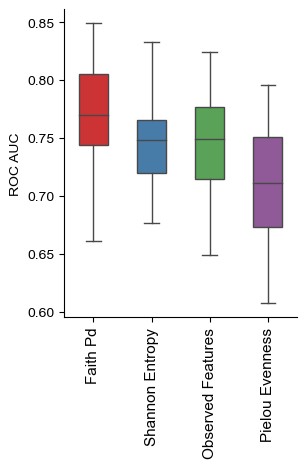

In [21]:
fig, ax = plt.subplots(figsize=(3, 4))
sns.boxplot(
    pd.DataFrame(diversity_clf_res),
    width=0.5,
    ax=ax,
    palette="Set1",
    linewidth=1,
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, fontfamily="Arial", rotation=90)
ax.set_ylabel(
    "ROC AUC",
    fontfamily="Arial",
)
sns.despine()

plt.savefig(
    "../../figures/ml_analysis/diversity_clr_performance.png",
    dpi=300,
    bbox_inches="tight",
)

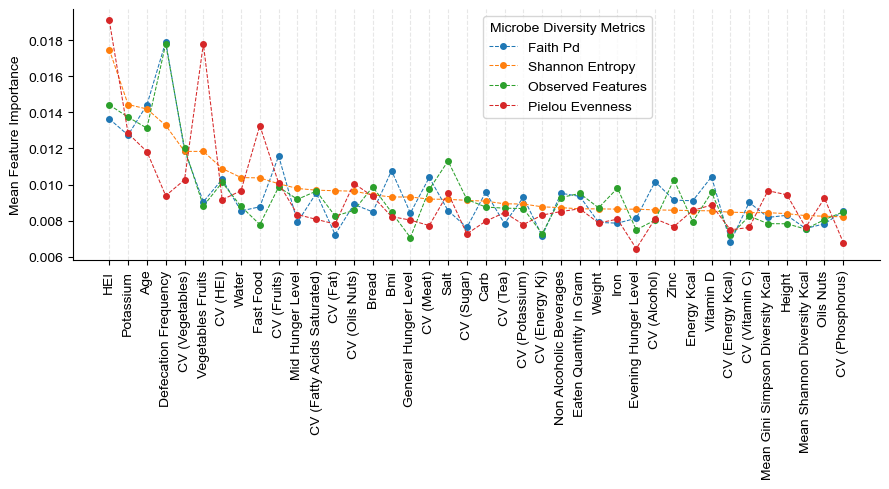

In [22]:
def create_lineplot(df, figsize=(12, 6), marker="o"):
    """
    Create a line plot from the given dataframe showing all metrics.

    Parameters:
    -----------
    df : pandas.DataFrame or str
        DataFrame with metrics as columns and features as index,
        or string containing the data
    figsize : tuple, optional
        Figure size (width, height)
    marker : str, optional
        Marker style for data points

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    # Data preprocessing
    if isinstance(df, str):
        # Split the string into lines
        lines = df.strip().split("\n")
        # Extract headers and data
        headers = [
            "Feature",
            "shannon_entropy",
            "faith_pd",
            "pielou_evenness",
            "observed_features",
        ]

        # Parse the data
        data = []
        for line in lines[1:]:  # Skip the header line
            values = line.split()
            feature = values[0]
            metrics = [float(x) for x in values[1:]]
            data.append([feature] + metrics)

        df = pd.DataFrame(data, columns=headers)

    # Set Feature as index if it's not already
    if "Feature" in df.columns:
        df = df.set_index("Feature")

    df.index = df.index.map(lambda x: process_string(x, newLineSep=10))

    # Create the line plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot each metric
    for column in df.columns:
        ax.plot(
            df.index,
            df[column],
            marker=marker,
            label=column,
            linewidth=0.75,
            linestyle="--",
            markersize=4,  # Reduced marker size
        )

    # Customize the plot
    # plt.title("Metrics Comparison Across Features", pad=20)
    plt.xlabel("")
    plt.ylabel("Mean Feature Importance")

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=90, ha="center")

    # Add legend
    plt.legend(
        bbox_to_anchor=(0.5, 1),
        loc="upper left",
        title="Microbe Diversity Metrics",
        labels=[process_string(i, newLineSep=10) for i in df.columns],
    )

    # Add grid for better readability
    plt.grid(True, axis="x", alpha=0.3, linestyle="--")

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    return fig, ax


fig, ax = create_lineplot(diversity_clf_featImp_df[:40], figsize=(9, 5))
sns.despine()

plt.savefig(
    "../../figures/ml_analysis/diversity_clr_featImp.png", dpi=300, bbox_inches="tight"
)